# Assignment 3 - Transfer Learning with ResNet on BF and FL Images (Multi-Scale Cross-Attention)

This copy keeps the patient-level split and fixed preprocessing, and upgrades cross-attention to use both `layer3` and `layer4` feature maps with learned attention pooling.
- original cross-attention notebook remains untouched
- patient-level grouped split is preserved
- checkpoint and submission filenames are architecture-specific


## 1. Imports and Setup

Required Packages: 
```bash
pip install torch torchvision pandas matplotlib seaborn pillow
```

In [23]:
import csv
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from tqdm import tqdm
from paired_cell_dataset import PairedCellDataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
DEVICE


device(type='cuda')

In [24]:
ROOT = Path.cwd()
TRAIN_CSV = ROOT / 'train.csv'
SAMPLE_SUBMISSION_CSV = ROOT / 'sampleSubmission.csv'
BF_TRAIN_DIR = ROOT / 'BF' / 'train'
BF_TEST_DIR = ROOT / 'BF' / 'test'
FL_TRAIN_DIR = ROOT / 'FL' / 'train'
FL_TEST_DIR = ROOT / 'FL' / 'test'

required_paths = [
    TRAIN_CSV,
    SAMPLE_SUBMISSION_CSV,
    BF_TRAIN_DIR,
    BF_TEST_DIR,
    FL_TRAIN_DIR,
    FL_TEST_DIR,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('Missing required paths:\n' + '\n'.join(missing_paths))

print('Workspace root:', ROOT)
print('All required files and folders are available.')

Workspace root: d:\docs\assignment3
All required files and folders are available.


## 2. Load Data and Basic Information

In [25]:
train_df = pd.read_csv(TRAIN_CSV)
submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

num_bf_train = len(list(BF_TRAIN_DIR.glob('*.jpg')))
num_fl_train = len(list(FL_TRAIN_DIR.glob('*.jpg')))
num_bf_test = len(list(BF_TEST_DIR.glob('*.jpg')))
num_fl_test = len(list(FL_TEST_DIR.glob('*.jpg')))

print('train.csv shape:', train_df.shape)
print('sampleSubmission.csv shape:', submission_df.shape)
print('BF train images:', num_bf_train)
print('FL train images:', num_fl_train)
print('BF test images:', num_bf_test)
print('FL test images:', num_fl_test)

display(train_df.head())
display(submission_df.head())

train.csv shape: (114302, 2)
sampleSubmission.csv shape: (59040, 2)
BF train images: 114302
FL train images: 114302
BF test images: 59040
FL test images: 59040


,Name,Diagnosis
0,pat_03_image_1.jpg,1
1,pat_03_image_2.jpg,1
2,pat_03_image_3.jpg,1
3,pat_03_image_4.jpg,1
4,pat_03_image_5.jpg,1


,Name,Diagnosis
0,image_1.jpg,0.5
1,image_2.jpg,0.5
2,image_3.jpg,0.5
3,image_4.jpg,0.5
4,image_5.jpg,0.5


In [26]:
label_counts = train_df['Diagnosis'].value_counts().sort_index()
class_names = {0: 'Healthy', 1: 'Cancer'}

summary_df = pd.DataFrame({
    'Class': [class_names[idx] for idx in label_counts.index],
    'Count': label_counts.values,
    'Percentage': (label_counts.values / len(train_df) * 100).round(2),
})
summary_df

,Class,Count,Percentage
0,Healthy,70000,61.24
1,Cancer,44302,38.76


## 3. Visualization

C:\Users\muham\AppData\Local\Temp\ipykernel_20364\2387626009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Diagnosis', ax=axes[0], palette='viridis')
C:\Users\muham\AppData\Local\Temp\ipykernel_20364\2387626009.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', 'Cancer (1)'])


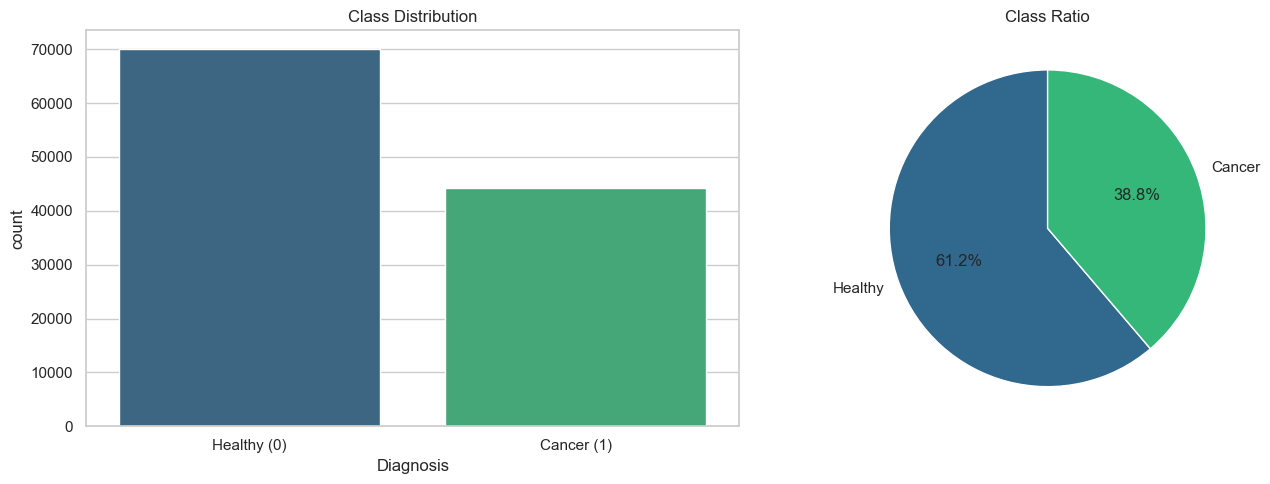

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='Diagnosis', ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Healthy (0)', 'Cancer (1)'])

axes[1].pie(
    label_counts.values,
    labels=[class_names[idx] for idx in label_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('viridis', n_colors=2),
)
axes[1].set_title('Class Ratio')

plt.tight_layout()
plt.show()

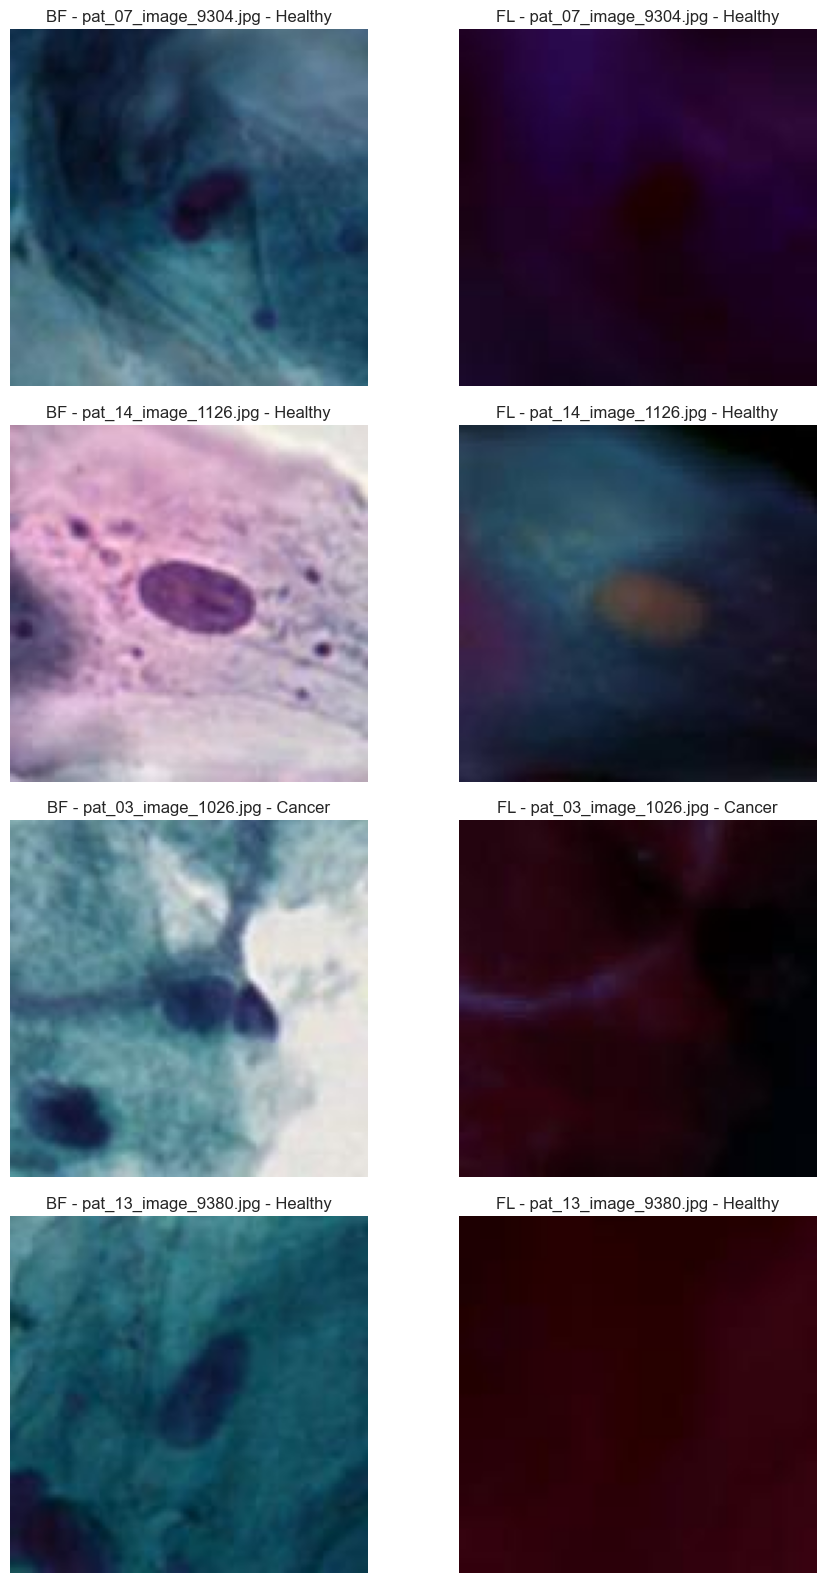

In [28]:
def show_paired_samples(dataframe, bf_dir, fl_dir, num_samples=4, seed=42):
    rng = random.Random(seed)
    sampled_rows = dataframe.sample(num_samples, random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = np.array([axes])

    for row_idx, row in sampled_rows.iterrows():
        image_name = row['Name']
        label = class_names[int(row['Diagnosis'])]

        bf_image = Image.open(bf_dir / image_name).convert('RGB')
        fl_image = Image.open(fl_dir / image_name).convert('RGB')

        axes[row_idx, 0].imshow(bf_image)
        axes[row_idx, 0].set_title(f'BF - {image_name} - {label}')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(fl_image)
        axes[row_idx, 1].set_title(f'FL - {image_name} - {label}')
        axes[row_idx, 1].axis('off')

    plt.tight_layout()
    plt.show()


show_paired_samples(train_df, BF_TRAIN_DIR, FL_TRAIN_DIR, num_samples=4, seed=SEED)

## 4. Train/Validation Split

In [29]:
@dataclass
class Record:
    name: str
    label: float | None


def extract_patient(name: str) -> str:
    # Expect filenames like 'pat_03_image_1.jpg' -> patient 'pat_03'
    if '_image' in name:
        return name.rsplit('_image', 1)[0]
    parts = name.split('_')
    return '_'.join(parts[:2]) if len(parts) >= 2 else parts[0]


def grouped_stratified_split(dataframe, val_ratio=0.15, seed=42):
    """Split by patient (not image) while stratifying by Diagnosis to prevent leakage."""
    df = dataframe.copy()
    df['patient_id'] = df['Name'].map(extract_patient)
    
    # Build patient-level labels (take mode if patient has mixed labels)
    patient_labels = df.groupby('patient_id')['Diagnosis'].agg(lambda x: x.mode().iat[0]).reset_index()
    
    train_patients = []
    val_patients = []
    
    # Stratified split on patients by class
    for label, group in patient_labels.groupby('Diagnosis'):
        patients = group['patient_id'].tolist()
        rng = random.Random(seed)
        rng.shuffle(patients)
        n_val = max(1, int(len(patients) * val_ratio))
        val_patients.extend(patients[:n_val])
        train_patients.extend(patients[n_val:])
    
    train_split = df[df['patient_id'].isin(train_patients)].drop(columns=['patient_id']).reset_index(drop=True)
    val_split = df[df['patient_id'].isin(val_patients)].drop(columns=['patient_id']).reset_index(drop=True)
    
    # Shuffle rows within splits
    train_split = train_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_split = val_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    
    return train_split, val_split


train_split_df, val_split_df = grouped_stratified_split(train_df, val_ratio=0.15, seed=SEED)

print('Training samples:', len(train_split_df))
print('Validation samples:', len(val_split_df))
display(train_split_df['Diagnosis'].value_counts().sort_index())
display(val_split_df['Diagnosis'].value_counts().sort_index())

Training samples: 94302
Validation samples: 20000


Diagnosis
0    60000
1    34302
Name: count, dtype: int64

Diagnosis
0    10000
1    10000
Name: count, dtype: int64

## 5. Dataset and DataLoaders

In [30]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
USE_AUGMENTATION = True
NUM_WORKERS = 0
NORMALIZATION_SAMPLE_SIZE = 4000


def estimate_channel_stats(image_paths, sample_size=NORMALIZATION_SAMPLE_SIZE, seed=SEED):
    image_paths = list(image_paths)
    if len(image_paths) > sample_size:
        rng = random.Random(seed)
        image_paths = rng.sample(image_paths, sample_size)

    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    total_pixels = 0

    for path in image_paths:
        with Image.open(path) as img:
            arr = np.asarray(img.convert('RGB'), dtype=np.float32) / 255.0
        flat = arr.reshape(-1, 3)
        channel_sum += flat.sum(axis=0)
        channel_sq_sum += (flat ** 2).sum(axis=0)
        total_pixels += flat.shape[0]

    mean = channel_sum / total_pixels
    std = np.sqrt(np.maximum(channel_sq_sum / total_pixels - mean ** 2, 1e-12))
    return tuple(mean.tolist()), tuple(std.tolist())


bf_train_paths_for_stats = [BF_TRAIN_DIR / name for name in train_split_df['Name']]
fl_train_paths_for_stats = [FL_TRAIN_DIR / name for name in train_split_df['Name']]

BF_MEAN, BF_STD = estimate_channel_stats(bf_train_paths_for_stats)
FL_MEAN, FL_STD = estimate_channel_stats(fl_train_paths_for_stats)

print('BF_MEAN:', BF_MEAN)
print('BF_STD :', BF_STD)
print('FL_MEAN:', FL_MEAN)
print('FL_STD :', FL_STD)


BF_MEAN: (0.4274062827648595, 0.5147086510173976, 0.5762043854407967)
BF_STD : (0.2625990019987785, 0.20751577805545404, 0.1737662849017131)
FL_MEAN: (0.15858876316645182, 0.07471112716789867, 0.09995363940674906)
FL_STD : (0.13365473168577613, 0.17535973894947826, 0.1528755609071602)


In [31]:
@dataclass(frozen=True)
class PairTransformRecipe:
    hflip: bool = False
    vflip: bool = False
    rotation_degrees: int = 0


class MicroscopyBasePairTransform:
    def __init__(self, image_size=IMAGE_SIZE, bf_mean=BF_MEAN, bf_std=BF_STD, fl_mean=FL_MEAN, fl_std=FL_STD):
        self.image_size = image_size
        self.bf_normalize = transforms.Normalize(bf_mean, bf_std)
        self.fl_normalize = transforms.Normalize(fl_mean, fl_std)

    def _resize(self, bf_image, fl_image):
        bf_image = TF.resize(bf_image, [self.image_size, self.image_size])
        fl_image = TF.resize(fl_image, [self.image_size, self.image_size])
        return bf_image, fl_image

    def _to_tensors(self, bf_image, fl_image):
        bf_tensor = self.bf_normalize(TF.to_tensor(bf_image))
        fl_tensor = self.fl_normalize(TF.to_tensor(fl_image))
        return bf_tensor, fl_tensor

    def __call__(self, bf_image, fl_image):
        bf_image, fl_image = self._resize(bf_image, fl_image)
        return self._to_tensors(bf_image, fl_image)


class MicroscopyAugmentedPairTransform(MicroscopyBasePairTransform):
    def __init__(
        self,
        image_size=IMAGE_SIZE,
        hflip_prob=0.5,
        vflip_prob=0.2,
        rotate_prob=0.4,
        brightness_jitter=0.12,
        contrast_jitter=0.12,
        blur_prob=0.15,
        bf_mean=BF_MEAN,
        bf_std=BF_STD,
        fl_mean=FL_MEAN,
        fl_std=FL_STD,
    ):
        super().__init__(image_size=image_size, bf_mean=bf_mean, bf_std=bf_std, fl_mean=fl_mean, fl_std=fl_std)
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.rotate_prob = rotate_prob
        self.brightness_jitter = brightness_jitter
        self.contrast_jitter = contrast_jitter
        self.blur_prob = blur_prob

    def _apply_intensity_ops(self, image):
        if self.brightness_jitter > 0:
            factor = 1.0 + random.uniform(-self.brightness_jitter, self.brightness_jitter)
            image = ImageEnhance.Brightness(image).enhance(factor)
        if self.contrast_jitter > 0:
            factor = 1.0 + random.uniform(-self.contrast_jitter, self.contrast_jitter)
            image = ImageEnhance.Contrast(image).enhance(factor)
        if random.random() < self.blur_prob:
            image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.15, 0.7)))
        return image

    def __call__(self, bf_image, fl_image):
        bf_image, fl_image = self._resize(bf_image, fl_image)

        if random.random() < self.hflip_prob:
            bf_image = TF.hflip(bf_image)
            fl_image = TF.hflip(fl_image)
        if random.random() < self.vflip_prob:
            bf_image = TF.vflip(bf_image)
            fl_image = TF.vflip(fl_image)
        if random.random() < self.rotate_prob:
            angle = random.choice([90, 180, 270])
            bf_image = TF.rotate(bf_image, angle)
            fl_image = TF.rotate(fl_image, angle)

        bf_image = self._apply_intensity_ops(bf_image)
        fl_image = self._apply_intensity_ops(fl_image)
        return self._to_tensors(bf_image, fl_image)


class MicroscopyFixedPairTransform(MicroscopyBasePairTransform):
    def __init__(self, image_size=IMAGE_SIZE, recipe=None, bf_mean=BF_MEAN, bf_std=BF_STD, fl_mean=FL_MEAN, fl_std=FL_STD):
        super().__init__(image_size=image_size, bf_mean=bf_mean, bf_std=bf_std, fl_mean=fl_mean, fl_std=fl_std)
        self.recipe = recipe or PairTransformRecipe()

    def __call__(self, bf_image, fl_image):
        bf_image, fl_image = self._resize(bf_image, fl_image)
        if self.recipe.hflip:
            bf_image = TF.hflip(bf_image)
            fl_image = TF.hflip(fl_image)
        if self.recipe.vflip:
            bf_image = TF.vflip(bf_image)
            fl_image = TF.vflip(fl_image)
        if self.recipe.rotation_degrees:
            bf_image = TF.rotate(bf_image, self.recipe.rotation_degrees)
            fl_image = TF.rotate(fl_image, self.recipe.rotation_degrees)
        return self._to_tensors(bf_image, fl_image)


AUGMENTATION_MODE = 'fixed_preprocessing'
AUGMENTATION_MULTIPLIER = 4
AUGMENTATION_MULTIPLIER = max(1, int(AUGMENTATION_MULTIPLIER))

base_transform = MicroscopyBasePairTransform(image_size=IMAGE_SIZE)
eval_transform = base_transform
train_augment_transform = MicroscopyAugmentedPairTransform(image_size=IMAGE_SIZE)

fixed_recipe_pool = [
    PairTransformRecipe(hflip=True),
    PairTransformRecipe(vflip=True),
    PairTransformRecipe(rotation_degrees=90),
    PairTransformRecipe(rotation_degrees=180),
    PairTransformRecipe(rotation_degrees=270),
]
selected_recipes = fixed_recipe_pool[: max(0, AUGMENTATION_MULTIPLIER - 1)]

test_df = submission_df[['Name']].copy()

train_dataset_original = PairedCellDataset(train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, base_transform, is_test=False)
augmented_datasets = []
if USE_AUGMENTATION:
    augmented_datasets.append(
        PairedCellDataset(train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, train_augment_transform, is_test=False)
    )
    augmented_datasets.extend([
        PairedCellDataset(
            train_split_df,
            BF_TRAIN_DIR,
            FL_TRAIN_DIR,
            MicroscopyFixedPairTransform(image_size=IMAGE_SIZE, recipe=recipe),
            is_test=False,
        )
        for recipe in selected_recipes
    ])

if augmented_datasets:
    train_dataset_augmented = ConcatDataset(augmented_datasets)
    train_dataset = ConcatDataset([train_dataset_original] + augmented_datasets)
else:
    train_dataset_augmented = None
    train_dataset = train_dataset_original

val_dataset = PairedCellDataset(val_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, eval_transform, is_test=False)
test_dataset = PairedCellDataset(test_df, BF_TEST_DIR, FL_TEST_DIR, eval_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

print('AUGMENTATION_MODE:', AUGMENTATION_MODE)
print('AUGMENTATION_MULTIPLIER:', AUGMENTATION_MULTIPLIER)
print('Fixed recipes used:', len(selected_recipes))
print('Original train samples:', len(train_dataset_original))
print('Augmented train samples:', 0 if train_dataset_augmented is None else len(train_dataset_augmented))
print('Combined train samples:', len(train_dataset))
print('Original image pairs are kept. Augmentation adds extra transformed copies; it does not replace the originals.')
print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Test batches:', len(test_loader))


AUGMENTATION_MODE: fixed_preprocessing
AUGMENTATION_MULTIPLIER: 4
Fixed recipes used: 3
Original train samples: 94302
Augmented train samples: 377208
Combined train samples: 471510
Original image pairs are kept. Augmentation adds extra transformed copies; it does not replace the originals.
Train batches: 14735
Validation batches: 625
Test batches: 1845


In [32]:
bf_batch, fl_batch, label_batch = next(iter(train_loader))
print('BF batch shape:', tuple(bf_batch.shape))
print('FL batch shape:', tuple(fl_batch.shape))
print('Label batch shape:', tuple(label_batch.shape))

BF batch shape: (32, 3, 128, 128)
FL batch shape: (32, 3, 128, 128)
Label batch shape: (32,)


## 6. Model: Two-Stream ResNet with Multi-Scale Cross-Attention


In [33]:
def get_backbone_config(backbone_name):
    if backbone_name == 'resnet18':
        return models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1, 512
    elif backbone_name == 'resnet34':
        return models.resnet34, models.ResNet34_Weights.IMAGENET1K_V1, 512
    elif backbone_name == 'resnet101':
        return models.resnet101, models.ResNet101_Weights.IMAGENET1K_V2, 2048
    return models.resnet50, models.ResNet50_Weights.IMAGENET1K_V2, 2048


class ResNetMultiScaleBackbone(nn.Module):
    def __init__(self, backbone_name='resnet50'):
        super().__init__()
        backbone_fn, weights, feature_dim = get_backbone_config(backbone_name)
        backbone = backbone_fn(weights=weights)
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.feature_dim = feature_dim
        self.layer3_dim = feature_dim // 2
        self.layer4_dim = feature_dim

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        layer3_map = self.layer3(x)
        layer4_map = self.layer4(layer3_map)
        return layer3_map, layer4_map


class CrossAttentionPoolingBlock(nn.Module):
    def __init__(self, input_dim, attention_dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.bf_projection = nn.Linear(input_dim, attention_dim)
        self.fl_projection = nn.Linear(input_dim, attention_dim)
        self.bf_to_fl_attention = nn.MultiheadAttention(attention_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.fl_to_bf_attention = nn.MultiheadAttention(attention_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm_bf = nn.LayerNorm(attention_dim)
        self.norm_fl = nn.LayerNorm(attention_dim)
        self.bf_pool = nn.Linear(attention_dim, 1)
        self.fl_pool = nn.Linear(attention_dim, 1)

    @staticmethod
    def _to_tokens(feature_map):
        return feature_map.flatten(2).transpose(1, 2)

    def _attention_pool(self, tokens, scorer):
        weights = torch.softmax(scorer(tokens).squeeze(-1), dim=1)
        pooled = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        return pooled

    def forward(self, bf_map, fl_map):
        bf_tokens = self.bf_projection(self._to_tokens(bf_map))
        fl_tokens = self.fl_projection(self._to_tokens(fl_map))

        bf_attended, _ = self.bf_to_fl_attention(bf_tokens, fl_tokens, fl_tokens)
        fl_attended, _ = self.fl_to_bf_attention(fl_tokens, bf_tokens, bf_tokens)

        bf_tokens = self.norm_bf(bf_tokens + bf_attended)
        fl_tokens = self.norm_fl(fl_tokens + fl_attended)

        bf_summary = self._attention_pool(bf_tokens, self.bf_pool)
        fl_summary = self._attention_pool(fl_tokens, self.fl_pool)
        return bf_summary, fl_summary


class TwoStreamResNet(nn.Module):
    def __init__(self, backbone_name='resnet50', dropout=0.3, attention_dim=256, num_heads=8):
        super().__init__()
        self.bf_backbone = ResNetMultiScaleBackbone(backbone_name)
        self.fl_backbone = ResNetMultiScaleBackbone(backbone_name)

        self.layer3_fusion = CrossAttentionPoolingBlock(
            input_dim=self.bf_backbone.layer3_dim,
            attention_dim=attention_dim,
            num_heads=num_heads,
            dropout=dropout,
        )
        self.layer4_fusion = CrossAttentionPoolingBlock(
            input_dim=self.bf_backbone.layer4_dim,
            attention_dim=attention_dim,
            num_heads=num_heads,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(attention_dim * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, bf_images, fl_images):
        bf_layer3, bf_layer4 = self.bf_backbone(bf_images)
        fl_layer3, fl_layer4 = self.fl_backbone(fl_images)

        bf_layer3_summary, fl_layer3_summary = self.layer3_fusion(bf_layer3, fl_layer3)
        bf_layer4_summary, fl_layer4_summary = self.layer4_fusion(bf_layer4, fl_layer4)

        layer3_abs_diff = torch.abs(bf_layer3_summary - fl_layer3_summary)
        layer3_product = bf_layer3_summary * fl_layer3_summary
        layer4_abs_diff = torch.abs(bf_layer4_summary - fl_layer4_summary)
        layer4_product = bf_layer4_summary * fl_layer4_summary

        fused = torch.cat([
            bf_layer3_summary,
            fl_layer3_summary,
            layer3_abs_diff,
            layer3_product,
            bf_layer4_summary,
            fl_layer4_summary,
            layer4_abs_diff,
            layer4_product,
        ], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

    def set_backbone_trainable(self, trainable):
        for module in [self.bf_backbone, self.fl_backbone]:
            for param in module.parameters():
                param.requires_grad = trainable


# Model initialization is configured in the next cell.



In [34]:
BACKBONE_NAME = 'resnet18'
DROPOUT = 0.3

# Choose one: 'imagenet', 'checkpoint', or 'pcam'
PRETRAIN_SOURCE = 'pcam'
PRETRAIN_CHECKPOINT_PATH = ROOT / 'outputs' / 'best_resnet_transfer_fixed_preproc_cross_attention copy.pt'
PRETRAIN_PCAM_PATH = ROOT / 'pretrained' / 'resnet18-pcam.pth'


def remap_checkpoint_key(key: str) -> str:
    stem_mappings = {
        'bf_backbone.conv1.': 'bf_backbone.stem.0.',
        'bf_backbone.bn1.': 'bf_backbone.stem.1.',
        'fl_backbone.conv1.': 'fl_backbone.stem.0.',
        'fl_backbone.bn1.': 'fl_backbone.stem.1.',
    }
    for old_prefix, new_prefix in stem_mappings.items():
        if key.startswith(old_prefix):
            return new_prefix + key[len(old_prefix):]
    return key


def load_compatible_checkpoint_weights(model: nn.Module, checkpoint_path: Path):
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model_state = model.state_dict()

    compatible_state = {}
    skipped = []
    for original_key, value in state_dict.items():
        mapped_key = remap_checkpoint_key(original_key)
        if mapped_key in model_state and model_state[mapped_key].shape == value.shape:
            compatible_state[mapped_key] = value
        else:
            skipped.append(original_key)

    missing_before_load = [key for key in model_state.keys() if key not in compatible_state]
    load_result = model.load_state_dict(compatible_state, strict=False)

    print(f'Loaded {len(compatible_state)} compatible tensors from {checkpoint_path.name}')
    print(f'Skipped {len(skipped)} source tensors with unmatched names or shapes')
    print(f'Model tensors left at current initialization: {len(missing_before_load)}')
    if skipped:
        print('First skipped keys:', skipped[:10])
    if load_result.missing_keys:
        print('First missing model keys:', load_result.missing_keys[:10])
    if load_result.unexpected_keys:
        print('First unexpected keys after filtering:', load_result.unexpected_keys[:10])

    return checkpoint


def load_pcam_resnet_weights_into_twostream(model: nn.Module, pcam_path: Path):
    """Load a single-stream ResNet (pcam) state dict into both bf_backbone and fl_backbone.
    This maps `conv1` -> `stem.0` and `bn1` -> `stem.1`, and prefixes other keys with the two backbone names.
    """
    if not pcam_path.exists():
        raise FileNotFoundError(f'PCAM weights not found: {pcam_path}')

    checkpoint = torch.load(pcam_path, map_location=DEVICE)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    # state_dict may already be a plain dict of tensors
    if not isinstance(state_dict, dict):
        raise ValueError('Unexpected PCAM checkpoint format')

    model_state = model.state_dict()
    compatible_state = {}
    skipped = []

    for original_key, value in state_dict.items():
        src_key = original_key
        if src_key.startswith('module.'):
            src_key = src_key[len('module.'):]

        if src_key.startswith('conv1.'):
            mapped_sub = 'stem.0.' + src_key[len('conv1.'):]
        elif src_key.startswith('bn1.'):
            mapped_sub = 'stem.1.' + src_key[len('bn1.'):]
        else:
            mapped_sub = src_key

        for prefix in ('bf_backbone', 'fl_backbone'):
            mapped_key = prefix + '.' + mapped_sub
            if mapped_key in model_state and model_state[mapped_key].shape == value.shape:
                compatible_state[mapped_key] = value
            else:
                skipped.append((original_key, mapped_key))

    missing_before_load = [key for key in model_state.keys() if key not in compatible_state]
    load_result = model.load_state_dict(compatible_state, strict=False)

    print(f'Loaded {len(compatible_state)} compatible tensors from {pcam_path.name}')
    print(f'Skipped {len(skipped)} source tensors with unmatched names or shapes')
    print(f'Model tensors left at current initialization: {len(missing_before_load)}')
    if skipped:
        print('First skipped key mappings (source->target):', skipped[:10])
    if load_result.missing_keys:
        print('First missing model keys:', load_result.missing_keys[:10])
    if load_result.unexpected_keys:
        print('First unexpected keys after filtering:', load_result.unexpected_keys[:10])

    return checkpoint


model = TwoStreamResNet(backbone_name=BACKBONE_NAME, dropout=DROPOUT).to(DEVICE)
initialization_summary = {'source': PRETRAIN_SOURCE}

if PRETRAIN_SOURCE == 'checkpoint':
    loaded_checkpoint = load_compatible_checkpoint_weights(model, PRETRAIN_CHECKPOINT_PATH)
    initialization_summary['checkpoint_path'] = str(PRETRAIN_CHECKPOINT_PATH)
    initialization_summary['checkpoint_best_val_auc'] = loaded_checkpoint.get('best_val_auc') if isinstance(loaded_checkpoint, dict) else None
elif PRETRAIN_SOURCE == 'pcam':
    loaded_pcam = load_pcam_resnet_weights_into_twostream(model, PRETRAIN_PCAM_PATH)
    initialization_summary['pcam_path'] = str(PRETRAIN_PCAM_PATH)
elif PRETRAIN_SOURCE != 'imagenet':
    raise ValueError("PRETRAIN_SOURCE must be one of 'imagenet', 'checkpoint', or 'pcam'.")
else:
    print('Using torchvision ImageNet initialization for the ResNet backbones.')

print('Backbone:', BACKBONE_NAME)
print('Dropout:', DROPOUT)
print('Initialization summary:', initialization_summary)
model


Loaded 0 compatible tensors from resnet18-pcam.pth
Skipped 244 source tensors with unmatched names or shapes
Model tensors left at current initialization: 284
First skipped key mappings (source->target): [('feat_extract.0.weight', 'bf_backbone.feat_extract.0.weight'), ('feat_extract.0.weight', 'fl_backbone.feat_extract.0.weight'), ('feat_extract.1.weight', 'bf_backbone.feat_extract.1.weight'), ('feat_extract.1.weight', 'fl_backbone.feat_extract.1.weight'), ('feat_extract.1.bias', 'bf_backbone.feat_extract.1.bias'), ('feat_extract.1.bias', 'fl_backbone.feat_extract.1.bias'), ('feat_extract.1.running_mean', 'bf_backbone.feat_extract.1.running_mean'), ('feat_extract.1.running_mean', 'fl_backbone.feat_extract.1.running_mean'), ('feat_extract.1.running_var', 'bf_backbone.feat_extract.1.running_var'), ('feat_extract.1.running_var', 'fl_backbone.feat_extract.1.running_var')]
First missing model keys: ['bf_backbone.stem.0.weight', 'bf_backbone.stem.1.weight', 'bf_backbone.stem.1.bias', 'bf_bac

TwoStreamResNet(
  (bf_backbone): ResNetMultiScaleBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2

## 7. Loss, Metrics, and Training Utilities

In [35]:
def run_epoch(model, loader, criterion, optimizer=None, desc='train', epoch=0, phase='train', start_batch_index=0):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    all_targets = []
    all_probs = []
    all_preds = []
    batch_history = []

    progress = tqdm(loader, total=len(loader), desc=desc, leave=False, dynamic_ncols=True)

    for step, (bf_images, fl_images, labels) in enumerate(progress, start=1):
        bf_images = bf_images.to(DEVICE, non_blocking=True)
        fl_images = fl_images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                logits = model(bf_images, fl_images)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        targets = labels.detach().cpu().numpy()
        preds = (probs >= 0.5).astype(np.int64)

        losses.append(loss.item())
        all_targets.extend(targets.tolist())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())

        batch_accuracy = float(np.mean(preds == targets.astype(np.int64)))
        running_loss = float(np.mean(losses))
        running_accuracy = float(np.mean(np.array(all_preds) == np.array(all_targets, dtype=np.int64)))
        running_auc = binary_auc_score(all_targets, all_probs)
        global_batch = start_batch_index + step

        batch_history.append({
            'epoch': epoch,
            'phase': phase,
            'batch_in_epoch': step,
            'global_batch': global_batch,
            'batch_loss': float(loss.item()),
            'batch_accuracy': batch_accuracy,
            'running_loss': running_loss,
            'running_accuracy': running_accuracy,
            'running_auc': running_auc,
        })

        if step % 20 == 0 or step == len(loader):
            progress.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_accuracy:.4f}", auc=f"{running_auc:.4f}")

    accuracy = float(np.mean(np.array(all_preds) == np.array(all_targets, dtype=np.int64)))
    auc = binary_auc_score(all_targets, all_probs)

    summary = {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy,
        'auc': auc,
    }

    return summary, batch_history


def predict(model, loader):
    model.eval()
    image_names = []
    probabilities = []

    with torch.no_grad():
        progress = tqdm(loader, total=len(loader), desc='predict', leave=False, dynamic_ncols=True)
        for bf_images, fl_images, names in progress:
            bf_images = bf_images.to(DEVICE, non_blocking=True)
            fl_images = fl_images.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                logits = model(bf_images, fl_images)

            probs = torch.sigmoid(logits).cpu().numpy().tolist()
            image_names.extend(names)
            probabilities.extend(float(p) for p in probs)

    return image_names, probabilities

## 8. Training

In [36]:
EPOCHS = 10
LEARNING_RATE = 1e-4
FREEZE_BACKBONE_EPOCHS = 5
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / 'best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt'


In [37]:
def binary_auc_score(targets, probabilities):
    targets = np.asarray(targets, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float64)

    positives = int(targets.sum())
    negatives = int(len(targets) - positives)
    if positives == 0 or negatives == 0:
        return float('nan')

    order = np.argsort(probabilities, kind='mergesort')
    sorted_probs = probabilities[order]
    sorted_targets = targets[order]

    rank_sum = 0.0
    start = 0
    n = len(sorted_probs)
    while start < n:
        end = start + 1
        while end < n and sorted_probs[end] == sorted_probs[start]:
            end += 1
        avg_rank = (start + end - 1) / 2.0 + 1.0
        positives_in_group = int(sorted_targets[start:end].sum())
        rank_sum += positives_in_group * avg_rank
        start = end

    return float((rank_sum - positives * (positives + 1) / 2.0) / (positives * negatives))


train_label_counts = train_split_df['Diagnosis'].value_counts().to_dict()
pos_weight_value = train_label_counts[0] / train_label_counts[1]

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# AMP is currently enabled only on CUDA; MPS/CPU run in full precision.
# USE_AMP = DEVICE.type == 'cuda'
USE_AMP = False
scaler = torch.amp.GradScaler(device='cuda', enabled=USE_AMP)

print('Positive class weight:', round(pos_weight_value, 4))
print('Device:', DEVICE)
print('AMP enabled:', USE_AMP)

Positive class weight: 1.7492
Device: cuda
AMP enabled: False


In [38]:
history = []
batch_history = []
best_val_auc = -math.inf
best_epoch = 0
epochs_without_improvement = 0
train_batch_offset = 0
val_batch_offset = 0

for epoch in range(1, EPOCHS + 1):
    model.set_backbone_trainable(epoch > FREEZE_BACKBONE_EPOCHS)

    start_time = time.time()
    train_metrics, train_batch_metrics = run_epoch(
        model, train_loader, criterion, optimizer, desc=f'E{epoch:02d} train', epoch=epoch, phase='train', start_batch_index=train_batch_offset
    )
    val_metrics, val_batch_metrics = run_epoch(
        model, val_loader, criterion, optimizer=None, desc=f'E{epoch:02d} val', epoch=epoch, phase='val', start_batch_index=val_batch_offset
    )
    batch_history.extend(train_batch_metrics)
    batch_history.extend(val_batch_metrics)
    train_batch_offset += len(train_batch_metrics)
    val_batch_offset += len(val_batch_metrics)
    scheduler.step()
    epoch_time = time.time() - start_time

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_auc': train_metrics['auc'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_auc': val_metrics['auc'],
        'epoch_time_sec': epoch_time,
    }
    history.append(row)

    prev_best_val_auc = best_val_auc
    improved = not math.isnan(val_metrics['auc']) and val_metrics['auc'] > best_val_auc
    if improved:
        improvement = val_metrics['auc'] - prev_best_val_auc if prev_best_val_auc > -math.inf else float('nan')
        best_val_auc = val_metrics['auc']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_auc': best_val_auc,
            'history': history,
            'batch_history': batch_history,
            'backbone_name': BACKBONE_NAME,
            'dropout': DROPOUT,
            'pretrain_source': PRETRAIN_SOURCE,
            'pretrain_checkpoint_path': str(PRETRAIN_CHECKPOINT_PATH) if PRETRAIN_SOURCE == 'checkpoint' else None,
        }, CHECKPOINT_PATH)
        print('Saved best model to', CHECKPOINT_PATH)
    else:
        improvement = val_metrics['auc'] - prev_best_val_auc if prev_best_val_auc > -math.inf and not math.isnan(val_metrics['auc']) else float('nan')
        epochs_without_improvement += 1

    lr_now = optimizer.param_groups[0]['lr']
    if improved:
        status = 'IMPROVED' if math.isnan(improvement) else f'IMPROVED (+{improvement:.4f})'
    else:
        status = 'NO IMPROVEMENT' if math.isnan(improvement) else f'NO IMPROVEMENT ({improvement:.4f})'

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} train_auc={train_metrics['auc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} val_auc={val_metrics['auc']:.4f} | "
        f"best_val_auc={best_val_auc:.4f} (epoch {best_epoch}) | "
        f"status={status} | no_improve={epochs_without_improvement} | "
        f"lr={lr_now:.2e} | time={epoch_time:.1f}s"
    )

history_df = pd.DataFrame(history)
batch_history_df = pd.DataFrame(batch_history)
display(history_df)
batch_history_df.head()

E01 train:   0%|          | 0/14735 [00:00<?, ?it/s]

Saved best model to d:\docs\assignment3\outputs\best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt
Epoch 01/10 | train_loss=0.1592 train_acc=0.9495 train_auc=0.9904 | val_loss=0.7527 val_acc=0.7556 val_auc=0.8395 | best_val_auc=0.8395 (epoch 1) | status=IMPROVED | no_improve=0 | lr=9.76e-05 | time=7329.0s


Epoch 02/10 | train_loss=0.0998 train_acc=0.9696 train_auc=0.9962 | val_loss=1.0533 val_acc=0.7214 val_auc=0.7976 | best_val_auc=0.8395 (epoch 1) | status=NO IMPROVEMENT (-0.0418) | no_improve=1 | lr=9.05e-05 | time=5981.3s


Saved best model to d:\docs\assignment3\outputs\best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt
Epoch 03/10 | train_loss=0.0780 train_acc=0.9763 train_auc=0.9976 | val_loss=0.9232 val_acc=0.7650 val_auc=0.8536 | best_val_auc=0.8536 (epoch 3) | status=IMPROVED (+0.0141) | no_improve=0 | lr=7.94e-05 | time=5906.4s


Saved best model to d:\docs\assignment3\outputs\best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt
Epoch 04/10 | train_loss=0.0624 train_acc=0.9812 train_auc=0.9985 | val_loss=0.8720 val_acc=0.7856 val_auc=0.8642 | best_val_auc=0.8642 (epoch 4) | status=IMPROVED (+0.0106) | no_improve=0 | lr=6.55e-05 | time=6525.3s


...

Epoch 08/10 | train_loss=0.0101 train_acc=0.9972 train_auc=1.0000 | val_loss=1.3464 val_acc=0.7785 val_auc=0.8990 | best_val_auc=0.9135 (epoch 7) | status=NO IMPROVEMENT (-0.0145) | no_improve=1 | lr=9.55e-06 | time=5829.9s


Epoch 09/10 | train_loss=0.0043 train_acc=0.9989 train_auc=1.0000 | val_loss=1.2321 val_acc=0.8078 val_auc=0.9103 | best_val_auc=0.9135 (epoch 7) | status=NO IMPROVEMENT (-0.0032) | no_improve=2 | lr=2.45e-06 | time=5912.2s


Epoch 10/10 | train_loss=0.0022 train_acc=0.9995 train_auc=1.0000 | val_loss=1.2481 val_acc=0.7994 val_auc=0.8891 | best_val_auc=0.9135 (epoch 7) | status=NO IMPROVEMENT (-0.0244) | no_improve=3 | lr=0.00e+00 | time=5732.9s


,epoch,train_loss,train_accuracy,train_auc,val_loss,val_accuracy,val_auc,epoch_time_sec
0,1,0.159202,0.949471,0.990413,0.752745,0.75555,0.839455,7328.967526
1,2,0.099793,0.969610,0.996160,1.053295,0.72140,0.797649,5981.343282
2,3,0.077974,0.976289,0.997638,0.923159,0.76500,0.853552,5906.404058
3,4,0.062389,0.981237,0.998473,0.872016,0.78560,0.864192,6525.313473
4,5,0.051951,0.984537,0.998942,1.223270,0.72855,0.806683,5742.344539
5,6,0.049628,0.985542,0.999019,0.832314,0.79045,0.869880,6099.258334
6,7,0.020954,0.994043,0.999818,0.779972,0.83170,0.913549,6130.265555
7,8,0.010055,0.997171,0.999956,1.346361,0.77850,0.899029,5829.902199
8,9,0.004329,0.998880,0.999991,1.232088,0.80785,0.910332,5912.177979
9,10,0.002207,0.999487,0.999997,1.248121,0.79935,0.889143,5732.907893


,epoch,phase,batch_in_epoch,global_batch,batch_loss,batch_accuracy,running_loss,running_accuracy,running_auc
0,1,train,1,1,0.849731,0.46875,0.849731,0.468750,0.458937
1,1,train,2,2,0.898665,0.62500,0.874198,0.546875,0.487265
2,1,train,3,3,0.858030,0.68750,0.868809,0.593750,0.527344
3,1,train,4,4,0.900607,0.75000,0.876758,0.632812,0.565748
4,1,train,5,5,0.762896,0.65625,0.853986,0.637500,0.600409


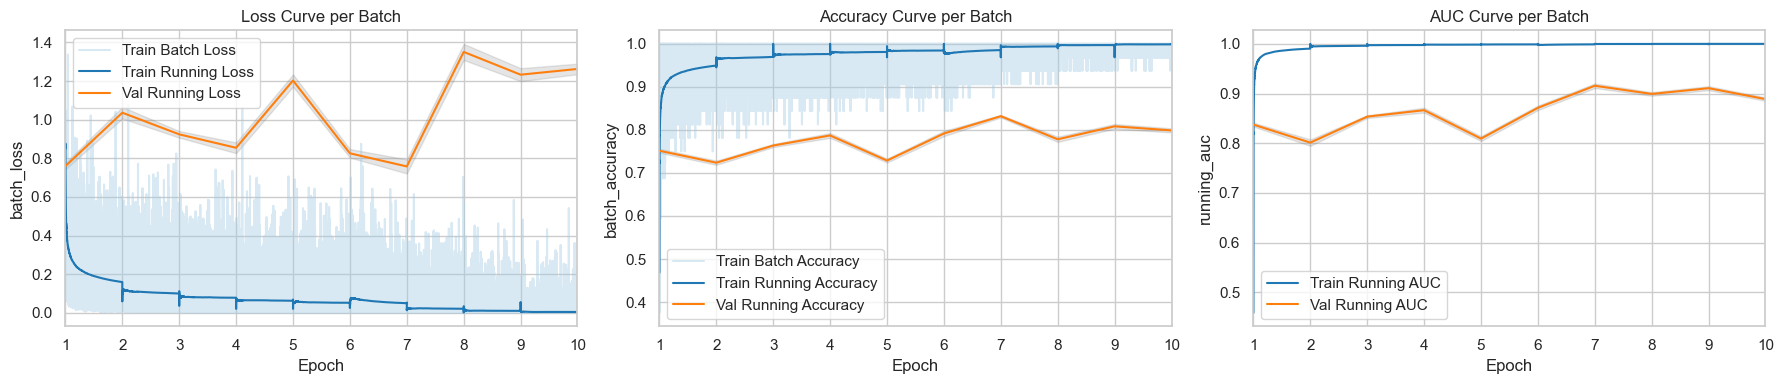

In [39]:
train_batch_df = batch_history_df[batch_history_df['phase'] == 'train'].copy()
val_batch_df = batch_history_df[batch_history_df['phase'] == 'val'].copy()

# Keep every batch point, but express x as fractional epoch position
train_batches_per_epoch = train_batch_df.groupby('epoch')['batch_in_epoch'].transform('max').clip(lower=1)
val_batches_per_epoch = val_batch_df.groupby('epoch')['batch_in_epoch'].transform('max').clip(lower=1)
train_batch_df['epoch_x'] = (train_batch_df['epoch'] - 1) + (train_batch_df['batch_in_epoch'] - 1) / train_batches_per_epoch
val_batch_df['epoch_x'] = (val_batch_df['epoch'] - 1) + (val_batch_df['batch_in_epoch'] - 1) / val_batches_per_epoch

# Validation lines per epoch with gray uncertainty bands (mean +/- std)
val_epoch_df = val_batch_df.groupby('epoch', as_index=False).agg(
    val_loss_mean=('running_loss', 'mean'),
    val_loss_std=('running_loss', 'std'),
    val_acc_mean=('running_accuracy', 'mean'),
    val_acc_std=('running_accuracy', 'std'),
    val_auc_mean=('running_auc', 'mean'),
    val_auc_std=('running_auc', 'std'),
)
val_epoch_df = val_epoch_df.fillna(0.0)
val_epoch_df['epoch_x'] = val_epoch_df['epoch'] - 1

TRAIN_BATCH_COLOR = '#9ecae1'
TRAIN_RUNNING_COLOR = '#1f77b4'
VAL_RUNNING_COLOR = '#ff7f0e'

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=train_batch_df, x='epoch_x', y='batch_loss', ax=axes[0], label='Train Batch Loss', alpha=0.40, color=TRAIN_BATCH_COLOR)
sns.lineplot(data=train_batch_df, x='epoch_x', y='running_loss', ax=axes[0], label='Train Running Loss', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_loss_mean', ax=axes[0], label='Val Running Loss', color=VAL_RUNNING_COLOR)
axes[0].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_loss_mean'] - val_epoch_df['val_loss_std'],
    val_epoch_df['val_loss_mean'] + val_epoch_df['val_loss_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[0].set_title('Loss Curve per Batch')
axes[0].set_xlabel('Epoch')

sns.lineplot(data=train_batch_df, x='epoch_x', y='batch_accuracy', ax=axes[1], label='Train Batch Accuracy', alpha=0.40, color=TRAIN_BATCH_COLOR)
sns.lineplot(data=train_batch_df, x='epoch_x', y='running_accuracy', ax=axes[1], label='Train Running Accuracy', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_acc_mean', ax=axes[1], label='Val Running Accuracy', color=VAL_RUNNING_COLOR)
axes[1].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_acc_mean'] - val_epoch_df['val_acc_std'],
    val_epoch_df['val_acc_mean'] + val_epoch_df['val_acc_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[1].set_title('Accuracy Curve per Batch')
axes[1].set_xlabel('Epoch')

sns.lineplot(data=train_batch_df, x='epoch_x', y='running_auc', ax=axes[2], label='Train Running AUC', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_auc_mean', ax=axes[2], label='Val Running AUC', color=VAL_RUNNING_COLOR)
axes[2].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_auc_mean'] - val_epoch_df['val_auc_std'],
    val_epoch_df['val_auc_mean'] + val_epoch_df['val_auc_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[2].set_title('AUC Curve per Batch')
axes[2].set_xlabel('Epoch')

if not history_df.empty:
    max_epoch = int(history_df['epoch'].max())
    epoch_ticks = np.arange(0, max_epoch, 1)
    epoch_labels = np.arange(1, max_epoch + 1, 1)
    for ax in axes:
        ax.set_xticks(epoch_ticks)
        ax.set_xticklabels(epoch_labels)
        ax.set_xlim(left=0, right=max(float(max_epoch - 1), 0.0))

plt.tight_layout()
plt.show()

In [40]:
import numpy as np
from matplotlib import pyplot as plt

def training_curve_plot(title, train_costs, test_costs, train_accuracy, test_accuracy, batch_size, learning_rate, num_epochs, elapsed, filename = "./Figures/training_curve.png"):
    # Plot training curves in a format recomended for Hand-in assignment 1 and 2
    #
    # Input
    # title - title for the plot
    # train_costs - Array of training costs (per batch)
    # test_costs - Array of test costs (per epoch)
    # train_accuracies - Array of training accuracies (per batch)
    # test_accuracies - Array of test accuracies (per epoch)
    # batch_size - batch size for training data used during training
    # num_epochs - Number of epochs used during training
    # elapsed - Time elapsed in seconds during training

    lg=18
    md=13
    sm=9
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, y=1.15, fontsize=lg)    
    elapsed_min, elapsed_sec = divmod(elapsed, 60)
    sub = f'|  Batch size:{batch_size}  |  Learning rate:{learning_rate} | Number of Epochs:{num_epochs} | Training time: {elapsed_min:.0f} min {elapsed_sec:.1f} sec |'
    fig.text(0.5, 0.99, sub, ha='center', fontsize=md)

    x_train = np.arange(1, len(train_costs) + 1)
    batches_per_epoch = len(train_costs) / max(len(test_costs), 1)
    x_test = np.arange(1, len(test_costs) + 1) * batches_per_epoch

    axs[0].plot(x_train, train_costs, label=f'Final train cost: {train_costs[-1]:.4f}')
    axs[0].plot(x_test, test_costs, label=f'Final test cost: {test_costs[-1]:.4f}')

    # Mark optimal point (minimum test cost)
    min_test_cost_idx = np.argmin(test_costs)
    opt_x = x_test[min_test_cost_idx]
    opt_y = test_costs[min_test_cost_idx]
    axs[0].plot(opt_x, opt_y, 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2,
                label='Optimal')
    # Add dashed lines to axes
    axs[0].plot([opt_x, opt_x], [axs[0].get_ylim()[0], opt_y], 'r--', linewidth=1, alpha=0.7)
    axs[0].plot([axs[0].get_xlim()[0], opt_x], [opt_y, opt_y], 'r--', linewidth=1, alpha=0.7)
    # Add text annotation near the optimal point
    axs[0].annotate(f'Epoch {min_test_cost_idx + 1}\nBatch {opt_x:.0f}\nCost {opt_y:.4f}', 
                    xy=(opt_x, opt_y), xytext=(10, 10), textcoords='offset points',
                    fontsize=sm, color='red', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

    axs[0].set_title('Costs', fontsize=md)
    axs[0].set_xlabel('Epoch', fontsize=md)
    axs[0].set_ylabel('Cost', fontsize=md)
    axs[0].legend(fontsize=sm)
    axs[0].tick_params(axis='both', labelsize=sm)
    # Optionally use a logarithmic y-scale
    #axs[0].set_yscale('log')
    axs[1].plot(x_train, train_accuracy, label=f'Final Train AUC: {100*train_accuracy[-1]:.2f}%')
    axs[1].plot(x_test, test_accuracy, label=f'Final Test AUC: {100*test_accuracy[-1]:.2f}%')

    # Mark optimal point (maximum test accuracy)
    max_test_acc_idx = np.argmax(test_accuracy)
    opt_x = x_test[max_test_acc_idx]
    opt_y = test_accuracy[max_test_acc_idx]
    axs[1].plot(opt_x, opt_y, 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2,
                label='Optimal')
    # Add dashed lines to axes
    axs[1].plot([opt_x, opt_x], [axs[1].get_ylim()[0], opt_y], 'r--', linewidth=1, alpha=0.7)
    axs[1].plot([axs[1].get_xlim()[0], opt_x], [opt_y, opt_y], 'r--', linewidth=1, alpha=0.7)
    # Add text annotation near the optimal point
    axs[1].annotate(f'Epoch {max_test_acc_idx + 1}\nAcc {100*opt_y:.2f}%', 
                    xy=(opt_x, opt_y), xytext=(10, 10), textcoords='offset points',
                    fontsize=sm, color='red', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

    axs[1].set_title('AUC', fontsize=md)
    axs[1].set_xlabel('Training Batch', fontsize=md)
    axs[1].set_ylabel('AUC (%)', fontsize=sm)
    axs[1].legend(fontsize=sm)
    axs[1].tick_params(axis='both', labelsize=sm)     

    plt.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

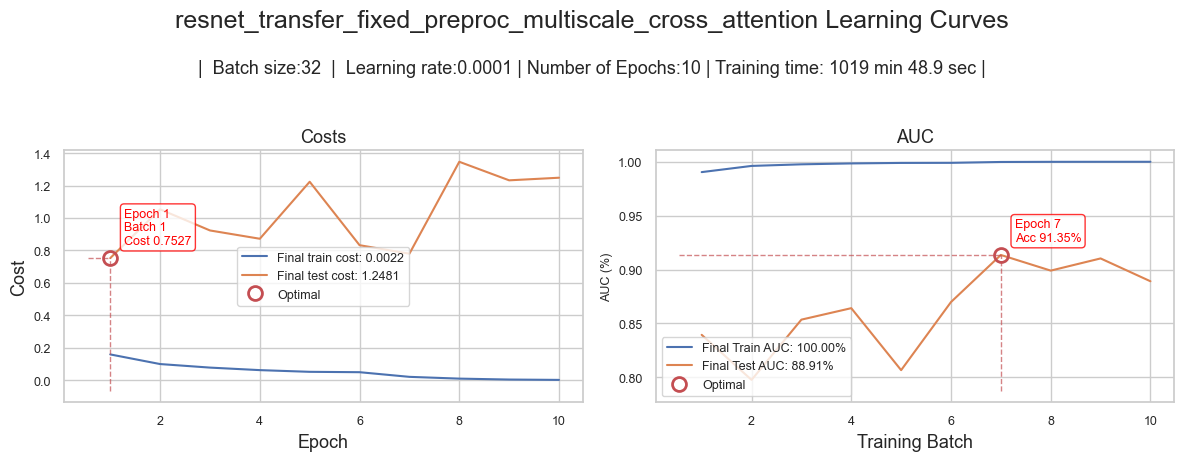

In [41]:
plot_model_name = 'resnet_transfer_fixed_preproc_multiscale_cross_attention'
train_losses = history_df['train_loss'].tolist()
val_losses = history_df['val_loss'].tolist()
train_accuracy = history_df['train_accuracy'].tolist()
val_accuracy = history_df['val_accuracy'].tolist()
train_auc = history_df['train_auc'].tolist()
val_auc = history_df['val_auc'].tolist()

batch_size = BATCH_SIZE
learning_rate = float(LEARNING_RATE)
num_epochs = int(history_df['epoch'].max()) if not history_df.empty else EPOCHS
training_time_seconds = float(history_df['epoch_time_sec'].sum()) if not history_df.empty else 0.0
output_dir = OUTPUT_DIR

training_curve_plot(
    title=f"{plot_model_name} Learning Curves",
    train_costs=train_losses,
    test_costs=val_losses,
    train_accuracy=train_auc,
    test_accuracy=val_auc,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    elapsed=training_time_seconds,
    filename=str(output_dir / f"{plot_model_name}_training_curve.png"),
)

## 9. Testing and Submission

In [42]:
CHECKPOINT_PATH = OUTPUT_DIR / 'best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
inference_backbone = checkpoint.get('backbone_name', BACKBONE_NAME)
inference_dropout = 0.0
model = TwoStreamResNet(backbone_name=inference_backbone, dropout=inference_dropout).to(DEVICE)


model.load_state_dict(checkpoint['model_state_dict'])
print('Loaded best model with validation AUC:', checkpoint['best_val_auc'])
print('Inference backbone:', inference_backbone)
print('Inference dropout:', inference_dropout)

# validation_loader_to_use = globals().get('val_loader_rebalanced', val_loader)
# validation_loader_name = 'val_loader_rebalanced' if 'val_loader_rebalanced' in globals() else 'val_loader'
# val_check_metrics, _ = run_epoch(
#     model,
#     validation_loader_to_use,
#     criterion,
#     optimizer=None,
#     desc=f'check {validation_loader_name}',
#     epoch=0,
#     phase='val',
# )
# print(f"Validation check on {validation_loader_name}: loss={val_check_metrics['loss']:.4f} acc={val_check_metrics['accuracy']:.4f} auc={val_check_metrics['auc']:.4f}")


Loaded best model with validation AUC: 0.9135494
Inference backbone: resnet18
Inference dropout: 0.0


In [43]:
test_names, test_probabilities = predict(model, test_loader)

submission = pd.DataFrame({
    'Name': test_names,
    'Diagnosis': test_probabilities,
})

submission_path = OUTPUT_DIR / 'submission_notebook_resnet_transfer_fixed_preproc_multiscale_cross_attention.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
display(submission.head())

tta_recipes = [
    PairTransformRecipe(),
    PairTransformRecipe(hflip=True),
    PairTransformRecipe(vflip=True),
    PairTransformRecipe(rotation_degrees=90),
    PairTransformRecipe(rotation_degrees=180),
    PairTransformRecipe(rotation_degrees=270),
]

def predict_with_tta(model, test_dataframe, recipes):
    tta_names = None
    tta_probability_sum = None

    for recipe in recipes:
        tta_transform = MicroscopyFixedPairTransform(image_size=IMAGE_SIZE, recipe=recipe)
        tta_dataset = PairedCellDataset(test_dataframe, BF_TEST_DIR, FL_TEST_DIR, tta_transform, is_test=True)
        tta_loader = DataLoader(
            tta_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=(DEVICE.type == 'cuda'),
        )

        current_names, current_probabilities = predict(model, tta_loader)
        current_probabilities = np.array(current_probabilities, dtype=np.float32)

        if tta_names is None:
            tta_names = current_names
            tta_probability_sum = current_probabilities
        else:
            if current_names != tta_names:
                raise RuntimeError('TTA predictions changed the test ordering.')
            tta_probability_sum += current_probabilities

    averaged_probabilities = (tta_probability_sum / len(recipes)).tolist()
    return tta_names, averaged_probabilities

tta_names, tta_probabilities = predict_with_tta(model, test_df, tta_recipes)

tta_submission = pd.DataFrame({
    'Name': tta_names,
    'Diagnosis': tta_probabilities,
})

tta_submission_path = OUTPUT_DIR / 'submission_notebook_resnet_transfer_fixed_preproc_multiscale_cross_attention_tta.csv'
tta_submission.to_csv(tta_submission_path, index=False)

print(f'TTA submission saved to: {tta_submission_path} using {len(tta_recipes)} views')
display(tta_submission.head())


Submission saved to: d:\docs\assignment3\outputs\submission_notebook_resnet_transfer_fixed_preproc_multiscale_cross_attention.csv


,Name,Diagnosis
0,image_1.jpg,0.334173
1,image_2.jpg,0.001376
2,image_3.jpg,0.003228
3,image_4.jpg,0.000634
4,image_5.jpg,0.000008


TTA submission saved to: d:\docs\assignment3\outputs\submission_notebook_resnet_transfer_fixed_preproc_multiscale_cross_attention_tta.csv using 6 views


,Name,Diagnosis
0,image_1.jpg,0.243478
1,image_2.jpg,0.000628
2,image_3.jpg,0.049126
3,image_4.jpg,0.000185
4,image_5.jpg,0.003889


## 10. Resume Training

This section is separate from the original training flow above. Run these cells from top to bottom: configure resume settings, load the checkpoint, rebuild the resumed split, rebuild loaders and loss, validate the loaded model on the new validation set, then continue training.

In [44]:
# Step 1: configure the resume run only.
resume_checkpoint_path = OUTPUT_DIR / 'best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt'
resume_target_epochs = 10  # total epoch number to reach after resuming
resume_freeze_backbone_epochs = 3  # backbone trains once epoch > this value during resume
resume_move_fraction = 0.25  # move this fraction of validation patients into training
resume_move_fraction = max(0.0, min(1.0, float(resume_move_fraction)))

required_names = ['train_split_df', 'val_split_df', 'base_transform', 'eval_transform']
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required notebook objects: {missing}. Run the notebook above first.")

print('Resume checkpoint path:', resume_checkpoint_path)
print('Resume target epochs:', resume_target_epochs)
print('Resume backbone freeze epochs:', resume_freeze_backbone_epochs)
print('Validation-to-train patient move fraction:', resume_move_fraction)


Resume checkpoint path: d:\docs\assignment3\outputs\best_resnet_transfer_fixed_preproc_multiscale_cross_attention.pt
Resume target epochs: 10
Resume backbone freeze epochs: 3
Validation-to-train patient move fraction: 0.25


In [45]:
# Step 2: build dedicated resume objects and load the checkpoint first.
device = DEVICE if 'DEVICE' in globals() else torch.device('cpu')
resume_backbone = globals().get('BACKBONE_NAME', 'resnet18')
resume_dropout = globals().get('DROPOUT', 0.3)
resume_learning_rate = globals().get('LEARNING_RATE', 1e-4)

resume_model = TwoStreamResNet(backbone_name=resume_backbone, dropout=resume_dropout).to(device)
resume_optimizer = torch.optim.AdamW(resume_model.parameters(), lr=resume_learning_rate, weight_decay=1e-4)
resume_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(resume_optimizer, T_max=max(int(resume_target_epochs), 1))
# resume_use_amp = device.type == 'cuda'
resume_use_amp = False

resume_start_epoch = 1
resume_best_val_auc = -math.inf
resume_history = []
resume_batch_history = []

if not resume_checkpoint_path.exists():
    raise FileNotFoundError(f'Resume checkpoint not found: {resume_checkpoint_path}')

resume_checkpoint = torch.load(resume_checkpoint_path, map_location=device)
resume_model.load_state_dict(resume_checkpoint['model_state_dict'])
print('Loaded model weights from checkpoint.')

if 'optimizer_state_dict' in resume_checkpoint:
    try:
        resume_optimizer.load_state_dict(resume_checkpoint['optimizer_state_dict'])
        print('Loaded optimizer state.')
    except Exception as exc:
        print('Warning: could not load optimizer state:', exc)

if 'scheduler_state_dict' in resume_checkpoint:
    try:
        resume_scheduler.load_state_dict(resume_checkpoint['scheduler_state_dict'])
        print('Loaded scheduler state.')
    except Exception as exc:
        print('Warning: could not load scheduler state:', exc)

saved_epoch = resume_checkpoint.get('epoch')
resume_start_epoch = int(saved_epoch) + 1 if saved_epoch is not None else 1
resume_best_val_auc = resume_checkpoint.get('best_val_auc', resume_best_val_auc)
resume_history = resume_checkpoint.get('history', [])
resume_batch_history = resume_checkpoint.get('batch_history', [])

print(f'Resume starts at epoch {resume_start_epoch}.')
print('Checkpoint best validation AUC:', resume_best_val_auc)
print('Stored history rows:', len(resume_history))
print('Stored batch-history rows:', len(resume_batch_history))


Loaded model weights from checkpoint.
Loaded optimizer state.
Resume starts at epoch 1.
Checkpoint best validation AUC: 0.9135494
Stored history rows: 7
Stored batch-history rows: 107520


In [46]:
# Step 3: move a balanced subset of validation patients into training.
from paired_transforms import FixedPairTransform

def resume_validation_patient_balance(dataframe):
    patient_labels = (
        dataframe.assign(patient_id=dataframe['Name'].map(extract_patient))
        .groupby('patient_id')['Diagnosis']
        .agg(lambda series: int(series.mode().iat[0]))
    )
    return patient_labels.value_counts().sort_index().to_dict()

def move_validation_patients_to_train_balanced(train_df, val_df, move_fraction=0.25, seed=42, min_val_patients_per_class=1):
    train_working = train_df.copy()
    val_working = val_df.copy()
    train_working['patient_id'] = train_working['Name'].map(extract_patient)
    val_working['patient_id'] = val_working['Name'].map(extract_patient)

    val_patient_labels = (
        val_working.groupby('patient_id')['Diagnosis']
        .agg(lambda series: int(series.mode().iat[0]))
        .reset_index()
    )
    if val_patient_labels.empty:
        raise RuntimeError('Validation split is empty before resume rebalancing.')

    rng = random.Random(seed)
    patients_by_label = {}
    for label, label_group in val_patient_labels.groupby('Diagnosis'):
        patients = label_group['patient_id'].tolist()
        rng.shuffle(patients)
        patients_by_label[int(label)] = patients

    if len(patients_by_label) > 1:
        requested_counts = []
        available_counts = []
        for patients in patients_by_label.values():
            available_to_move = max(0, len(patients) - int(min_val_patients_per_class))
            requested_to_move = int(round(len(patients) * move_fraction))
            if move_fraction > 0.0 and available_to_move > 0:
                requested_to_move = max(1, requested_to_move)
            requested_counts.append(requested_to_move)
            available_counts.append(available_to_move)
        move_count_per_class = min(min(requested_counts), min(available_counts))
    else:
        only_label_patients = next(iter(patients_by_label.values()))
        available_to_move = max(0, len(only_label_patients) - int(min_val_patients_per_class))
        requested_to_move = int(round(len(only_label_patients) * move_fraction))
        if move_fraction > 0.0 and available_to_move > 0:
            requested_to_move = max(1, requested_to_move)
        move_count_per_class = min(requested_to_move, available_to_move)

    moved_patients = []
    for patients in patients_by_label.values():
        moved_patients.extend(patients[:move_count_per_class])

    moved_patients = sorted(set(moved_patients))
    moved_rows = val_working[val_working['patient_id'].isin(moved_patients)].drop(columns=['patient_id'])
    remaining_val_rows = val_working[~val_working['patient_id'].isin(moved_patients)].drop(columns=['patient_id'])
    rebalanced_train_df = pd.concat([train_working.drop(columns=['patient_id']), moved_rows], ignore_index=True)
    rebalanced_val_df = remaining_val_rows.reset_index(drop=True)

    rebalanced_train_df = rebalanced_train_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    rebalanced_val_df = rebalanced_val_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    train_patients = set(rebalanced_train_df['Name'].map(extract_patient))
    val_patients = set(rebalanced_val_df['Name'].map(extract_patient))
    overlap = train_patients & val_patients
    if overlap:
        raise RuntimeError(f'Patient leakage detected after rebalancing: {sorted(list(overlap))[:5]}')
    if rebalanced_val_df.empty:
        raise RuntimeError('Rebalanced validation split became empty.')

    val_balance = resume_validation_patient_balance(rebalanced_val_df)
    if len(val_balance) > 1 and len(set(val_balance.values())) != 1:
        raise RuntimeError(f'Validation class balance was broken after rebalancing: {val_balance}')

    return rebalanced_train_df, rebalanced_val_df, moved_patients, val_balance

resume_train_split_df, resume_val_split_df, resume_moved_validation_patients, resume_val_balance = move_validation_patients_to_train_balanced(
    train_split_df,
    val_split_df,
    move_fraction=resume_move_fraction,
    seed=SEED,
)

print('Moved validation patients for resume:', len(resume_moved_validation_patients))
print('Resume train samples:', len(resume_train_split_df))
print('Resume val samples:', len(resume_val_split_df))
print('Resume validation patient balance:', resume_val_balance)


Moved validation patients for resume: 0
Resume train samples: 94302
Resume val samples: 20000
Resume validation patient balance: {0: 1, 1: 1}


In [47]:
# Step 4: rebuild the resumed train/validation loaders and the resumed loss.
resume_train_dataset_original = PairedCellDataset(resume_train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, base_transform, is_test=False)
resume_augmented_datasets = []
if USE_AUGMENTATION:
    resume_augmented_datasets.append(
        PairedCellDataset(resume_train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, train_augment_transform, is_test=False)
    )
    resume_augmented_datasets.extend([
        PairedCellDataset(
            resume_train_split_df,
            BF_TRAIN_DIR,
            FL_TRAIN_DIR,
            MicroscopyFixedPairTransform(image_size=IMAGE_SIZE, recipe=recipe),
            is_test=False,
        )
        for recipe in (selected_recipes if 'selected_recipes' in globals() else [])
    ])

if resume_augmented_datasets:
    resume_train_dataset = ConcatDataset([resume_train_dataset_original] + resume_augmented_datasets)
else:
    resume_train_dataset = resume_train_dataset_original

resume_val_dataset = PairedCellDataset(resume_val_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, eval_transform, is_test=False)
resume_train_loader = DataLoader(resume_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
resume_val_loader = DataLoader(resume_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

resume_train_label_counts = resume_train_split_df['Diagnosis'].value_counts().to_dict()
resume_train_negatives = int(resume_train_label_counts.get(0, 0))
resume_train_positives = int(resume_train_label_counts.get(1, 0))
resume_pos_weight = resume_train_negatives / max(resume_train_positives, 1)
resume_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([resume_pos_weight], dtype=torch.float32, device=device)
)

print('Resume train label counts:', resume_train_label_counts)
print('Resume pos_weight:', round(resume_pos_weight, 4))
print('Resume train batches:', len(resume_train_loader))
print('Resume val batches:', len(resume_val_loader))


Resume train label counts: {0: 60000, 1: 34302}
Resume pos_weight: 1.7492
Resume train batches: 14735
Resume val batches: 625


In [48]:
# Step 5: check the loaded checkpoint on the new validation split before training.
resume_val_metrics, _ = run_epoch(
    resume_model,
    resume_val_loader,
    resume_criterion,
    optimizer=None,
    desc='resume check val',
    epoch=0,
    phase='val',
)
print(f"Resume validation check: loss={resume_val_metrics['loss']:.4f} acc={resume_val_metrics['accuracy']:.4f} auc={resume_val_metrics['auc']:.4f}")


Resume validation check: loss=0.7800 acc=0.8317 auc=0.9135


In [49]:
# Step 6: continue training on the resumed split.
for epoch in range(resume_start_epoch, resume_target_epochs + 1):
    resume_backbone_trainable = epoch > resume_freeze_backbone_epochs
    resume_model.set_backbone_trainable(resume_backbone_trainable)

    t0 = time.time()
    train_metrics, train_batch_metrics = run_epoch(
        resume_model,
        resume_train_loader,
        resume_criterion,
        resume_optimizer,
        desc=f'R{epoch:02d} train',
        epoch=epoch,
        phase='train',
        start_batch_index=sum(1 for batch in resume_batch_history if batch.get('phase') == 'train'),
    )
    val_metrics, val_batch_metrics = run_epoch(
        resume_model,
        resume_val_loader,
        resume_criterion,
        optimizer=None,
        desc=f'R{epoch:02d} val',
        epoch=epoch,
        phase='val',
        start_batch_index=sum(1 for batch in resume_batch_history if batch.get('phase') == 'val'),
    )

    resume_batch_history.extend(train_batch_metrics)
    resume_batch_history.extend(val_batch_metrics)
    resume_scheduler.step()
    epoch_time = time.time() - t0

    resume_history.append({
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_auc': train_metrics['auc'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_auc': val_metrics['auc'],
        'epoch_time_sec': epoch_time,
    })

    improved = not math.isnan(val_metrics['auc']) and val_metrics['auc'] > resume_best_val_auc
    if improved:
        resume_best_val_auc = val_metrics['auc']
        torch.save({
            'model_state_dict': resume_model.state_dict(),
            'optimizer_state_dict': resume_optimizer.state_dict(),
            'scheduler_state_dict': resume_scheduler.state_dict(),
            'best_val_auc': resume_best_val_auc,
            'history': resume_history,
            'batch_history': resume_batch_history,
            'epoch': epoch,
        }, resume_checkpoint_path)
        print('Saved improved checkpoint to', resume_checkpoint_path)

    print(
        f"Resume Epoch {epoch}/{resume_target_epochs} | "
        f"train_loss={train_metrics['loss']:.4f} val_auc={val_metrics['auc']:.4f} "
        f"best_val_auc={resume_best_val_auc:.4f} backbone_trainable={resume_backbone_trainable} | time={epoch_time:.1f}s"
    )

globals()['resume_model'] = resume_model
globals()['resume_optimizer'] = resume_optimizer
globals()['resume_scheduler'] = resume_scheduler
globals()['resume_scaler'] = resume_scaler
globals()['resume_criterion'] = resume_criterion
globals()['resume_history'] = resume_history
globals()['resume_batch_history'] = resume_batch_history
globals()['resume_best_val_auc'] = resume_best_val_auc
globals()['resume_start_epoch'] = resume_start_epoch
globals()['resume_train_loader'] = resume_train_loader
globals()['resume_val_loader'] = resume_val_loader
globals()['resume_train_split_df'] = resume_train_split_df
globals()['resume_val_split_df'] = resume_val_split_df
globals()['resume_moved_validation_patients'] = resume_moved_validation_patients

print('Resume run complete. Resume objects were stored in the resume_* namespace.')


Resume Epoch 1/10 | train_loss=0.0084 val_auc=0.8879 best_val_auc=0.9135 backbone_trainable=False | time=5751.4s


KeyboardInterrupt: 